MILESTONE 3 – ENSEMBLE MODELS TRAINING & COMPARISON

[STEP 1] Loading and preparing data...
✓ Data loaded: 2200 rows, 7 features
✓ Target classes: 22 crops

[STEP 2] Splitting data...
✓ Training set: 1760 rows
✓ Test set: 440 rows

[STEP 3] Scaling features...
✓ Features scaled using StandardScaler

[STEP 4] Training ensemble models...

  Training Random Forest...
  ✓ Random Forest trained

  Training XGBoost...
  ✓ XGBoost trained

  Training Gradient Boosting...
  ✓ Gradient Boosting trained

  Training Extra Trees...
  ✓ Extra Trees trained

  Training AdaBoost...
  ✓ AdaBoost trained

[STEP 5] Evaluating all models...

MODEL PERFORMANCE COMPARISON

Random Forest:
  Accuracy:  99.55%
  Precision: 99.59%
  Recall:    99.55%
  F1 Score:  99.54%

XGBoost:
  Accuracy:  99.55%
  Precision: 99.55%
  Recall:    99.55%
  F1 Score:  99.55%

Gradient Boosting:
  Accuracy:  99.09%
  Precision: 99.15%
  Recall:    99.09%
  F1 Score:  99.09%

Extra Trees:
  Accuracy:  99.77%
  Precision: 99.78%


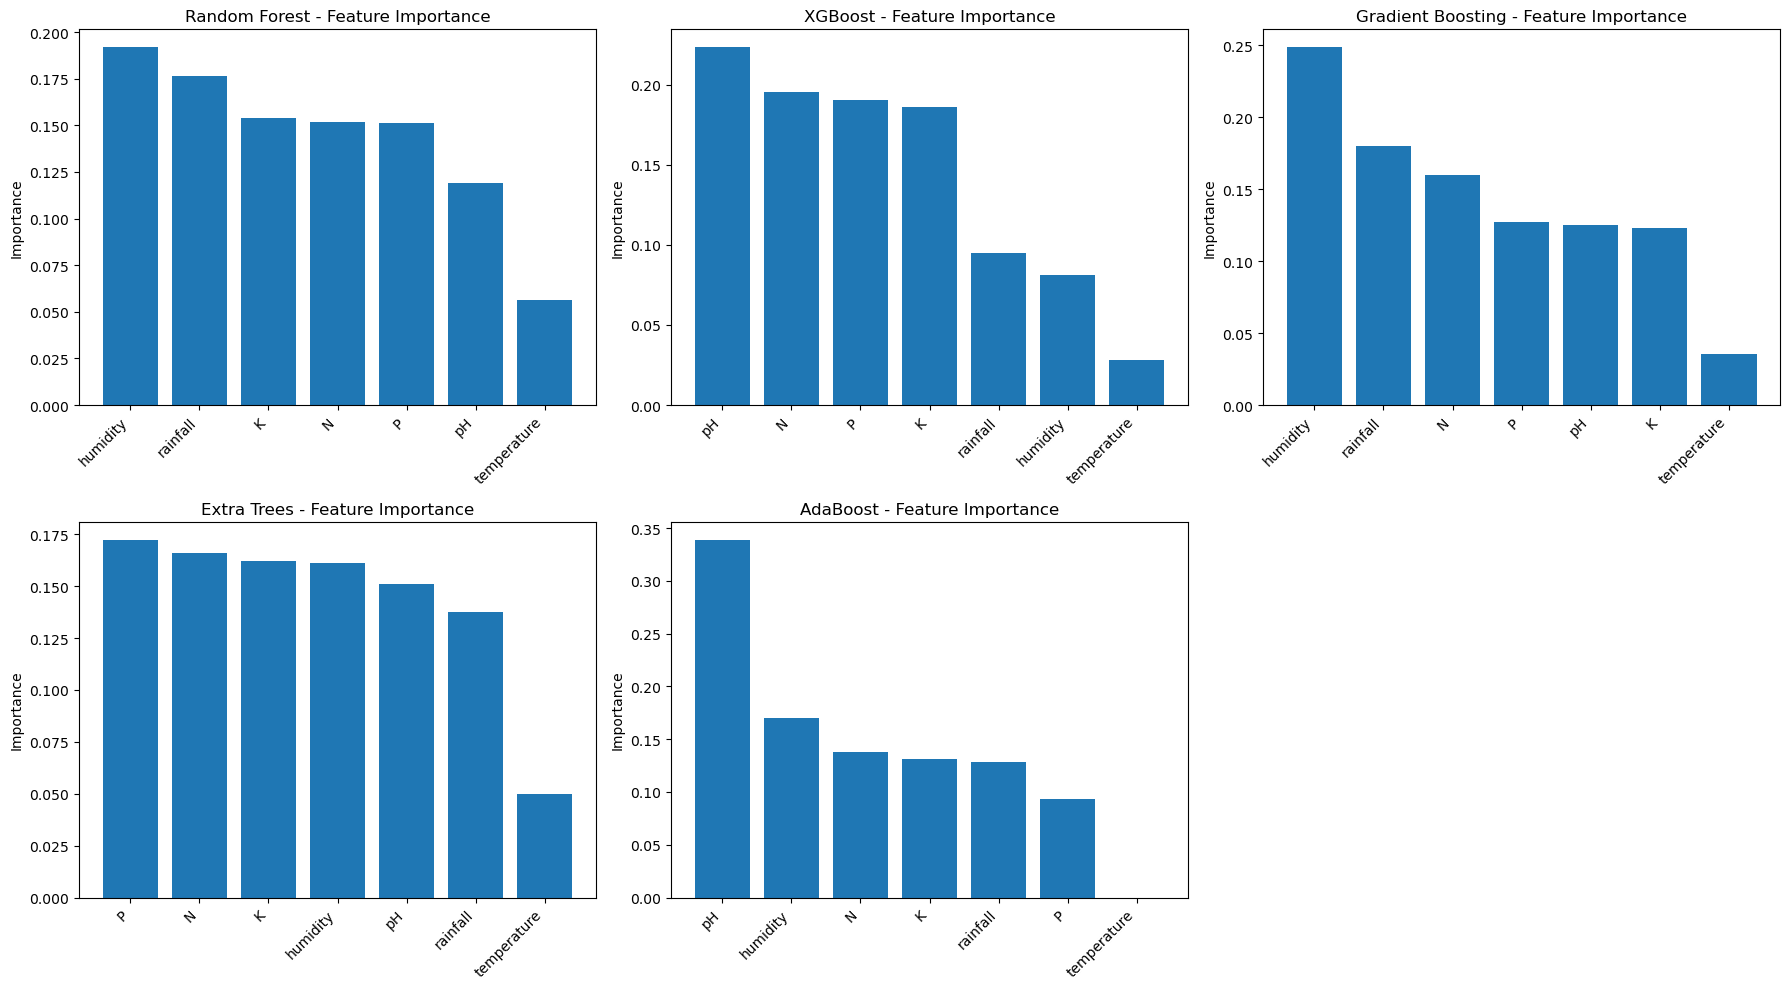


[STEP 8] Creating visualization...
✓ Saved: model_comparison.png


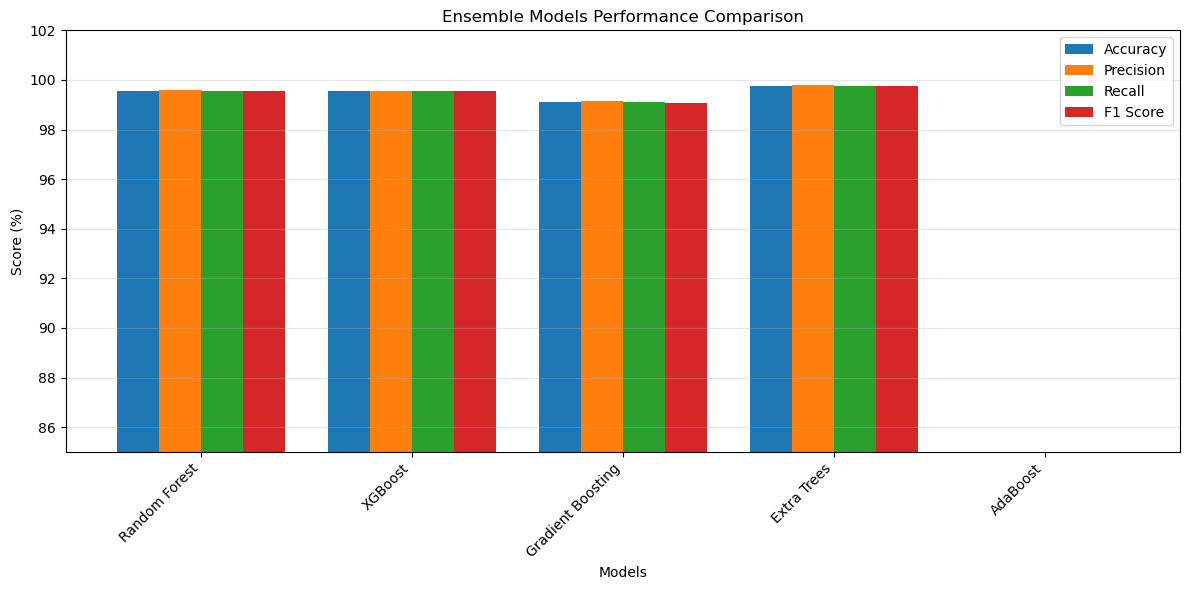


[STEP 9] Detailed classification report for best model...

DETAILED REPORT - Extra Trees
              precision    recall  f1-score   support

       apple     1.0000    1.0000    1.0000        20
      banana     1.0000    1.0000    1.0000        20
   blackgram     1.0000    1.0000    1.0000        20
    chickpea     1.0000    1.0000    1.0000        20
     coconut     1.0000    1.0000    1.0000        20
      coffee     1.0000    1.0000    1.0000        20
      cotton     1.0000    1.0000    1.0000        20
      grapes     1.0000    1.0000    1.0000        20
        jute     1.0000    0.9500    0.9744        20
 kidneybeans     1.0000    1.0000    1.0000        20
      lentil     1.0000    1.0000    1.0000        20
       maize     1.0000    1.0000    1.0000        20
       mango     1.0000    1.0000    1.0000        20
   mothbeans     1.0000    1.0000    1.0000        20
    mungbean     1.0000    1.0000    1.0000        20
   muskmelon     1.0000    1.0000    1.0000  

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
    ExtraTreesClassifier
)
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("=" * 70)
print("MILESTONE 3 – ENSEMBLE MODELS TRAINING & COMPARISON")
print("=" * 70)

# ============================================================
# STEP 1: LOAD AND PREPARE DATA
# ============================================================
print("\n[STEP 1] Loading and preparing data...")
data_df = pd.read_csv('cleaned_data.csv')

X = data_df.drop('Crop', axis=1)
y = data_df['Crop']

# Encode target
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print(f"✓ Data loaded: {len(data_df)} rows, {len(X.columns)} features")
print(f"✓ Target classes: {len(encoder.classes_)} crops")

# ============================================================
# STEP 2: SPLIT DATA
# ============================================================
print("\n[STEP 2] Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"✓ Training set: {len(X_train)} rows")
print(f"✓ Test set: {len(X_test)} rows")

# ============================================================
# STEP 3: SCALE FEATURES
# ============================================================
print("\n[STEP 3] Scaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Features scaled using StandardScaler")

# ============================================================
# STEP 4: TRAIN MULTIPLE ENSEMBLE MODELS
# ============================================================
print("\n[STEP 4] Training ensemble models...")

models = {}
predictions = {}
results = {}

# 1. Random Forest (Already trained in Milestone 2)
print("\n  Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
models['Random Forest'] = rf_model
predictions['Random Forest'] = rf_model.predict(X_test_scaled)
print("  ✓ Random Forest trained")

# 2. XGBoost
print("\n  Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb_model.fit(X_train_scaled, y_train)
models['XGBoost'] = xgb_model
predictions['XGBoost'] = xgb_model.predict(X_test_scaled)
print("  ✓ XGBoost trained")

# 3. Gradient Boosting
print("\n  Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
models['Gradient Boosting'] = gb_model
predictions['Gradient Boosting'] = gb_model.predict(X_test_scaled)
print("  ✓ Gradient Boosting trained")

# 4. Extra Trees (Extremely Randomized Trees)
print("\n  Training Extra Trees...")
et_model = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
et_model.fit(X_train_scaled, y_train)
models['Extra Trees'] = et_model
predictions['Extra Trees'] = et_model.predict(X_test_scaled)
print("  ✓ Extra Trees trained")

# 5. AdaBoost
print("\n  Training AdaBoost...")
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)
ada_model.fit(X_train_scaled, y_train)
models['AdaBoost'] = ada_model
predictions['AdaBoost'] = ada_model.predict(X_test_scaled)
print("  ✓ AdaBoost trained")

# ============================================================
# STEP 5: EVALUATE ALL MODELS
# ============================================================
print("\n[STEP 5] Evaluating all models...")
print("\n" + "=" * 70)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 70)

comparison_data = []

for model_name, y_pred in predictions.items():
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[model_name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }
    
    comparison_data.append({
        'Model': model_name,
        'Accuracy': f"{accuracy*100:.2f}%",
        'Precision': f"{precision*100:.2f}%",
        'Recall': f"{recall*100:.2f}%",
        'F1 Score': f"{f1*100:.2f}%"
    })
    
    print(f"\n{model_name}:")
    print(f"  Accuracy:  {accuracy*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1 Score:  {f1*100:.2f}%")

# Create comparison dataframe
comparison_df = pd.DataFrame(comparison_data)
print("\n" + "=" * 70)
print("SUMMARY TABLE")
print("=" * 70)
print(comparison_df.to_string(index=False))

# ============================================================
# STEP 6: FIND BEST MODEL
# ============================================================
print("\n[STEP 6] Finding best model...")

best_model_name = max(results, key=lambda x: results[x]['f1'])
best_model = models[best_model_name]
best_results = results[best_model_name]

print("\n" + "=" * 70)
print("🏆 BEST MODEL")
print("=" * 70)
print(f"Model: {best_model_name}")
print(f"Accuracy: {best_results['accuracy']*100:.2f}%")
print(f"Precision: {best_results['precision']*100:.2f}%")
print(f"Recall: {best_results['recall']*100:.2f}%")
print(f"F1 Score: {best_results['f1']*100:.2f}%")

# ============================================================
# STEP 7: FEATURE IMPORTANCE COMPARISON
# ============================================================
print("\n[STEP 7] Analyzing feature importance...")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

feature_names = X.columns

for idx, (model_name, model) in enumerate(models.items()):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1]
        
        axes[idx].bar(range(len(importances)), importances[indices])
        axes[idx].set_xticks(range(len(importances)))
        axes[idx].set_xticklabels(feature_names[indices], rotation=45, ha='right')
        axes[idx].set_title(f'{model_name} - Feature Importance')
        axes[idx].set_ylabel('Importance')

# Remove extra subplots
for idx in range(len(models), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: feature_importance_comparison.png")
plt.show()

# ============================================================
# STEP 8: ACCURACY COMPARISON VISUALIZATION
# ============================================================
print("\n[STEP 8] Creating visualization...")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = list(results.keys())

# Extract values for plotting
accuracy_values = [results[m]['accuracy']*100 for m in model_names]
precision_values = [results[m]['precision']*100 for m in model_names]
recall_values = [results[m]['recall']*100 for m in model_names]
f1_values = [results[m]['f1']*100 for m in model_names]

# Create bar plot
x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*width, accuracy_values, width, label='Accuracy')
ax.bar(x - 0.5*width, precision_values, width, label='Precision')
ax.bar(x + 0.5*width, recall_values, width, label='Recall')
ax.bar(x + 1.5*width, f1_values, width, label='F1 Score')

ax.set_xlabel('Models')
ax.set_ylabel('Score (%)')
ax.set_title('Ensemble Models Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.legend()
ax.set_ylim([85, 102])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: model_comparison.png")
plt.show()

# ============================================================
# STEP 9: DETAILED CLASSIFICATION REPORT FOR BEST MODEL
# ============================================================
print("\n[STEP 9] Detailed classification report for best model...")
print("\n" + "=" * 70)
print(f"DETAILED REPORT - {best_model_name}")
print("=" * 70)

best_predictions = predictions[best_model_name]
print(classification_report(y_test, best_predictions, 
                           target_names=encoder.classes_, 
                           digits=4))

# ============================================================
# STEP 10: SAVE BEST MODEL
# ============================================================
print("\n[STEP 10] Saving best model...")

joblib.dump(best_model, f'{best_model_name.lower().replace(" ", "_")}_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'label_encoder.pkl')

print(f"✓ Saved: {best_model_name.lower().replace(' ', '_')}_model.pkl")
print("✓ Saved: scaler.pkl")
print("✓ Saved: label_encoder.pkl")

# ============================================================
# STEP 11: HYPERPARAMETER TUNING (Optional)
# ============================================================
print("\n[STEP 11] Hyperparameter tuning for best model...")

from sklearn.model_selection import GridSearchCV

if best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [4, 6, 8],
        'learning_rate': [0.01, 0.1, 0.3]
    }
    
    print("\nTuning XGBoost hyperparameters...")
    grid_search = GridSearchCV(
        XGBClassifier(random_state=42, verbosity=0),
        param_grid,
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )
    
    grid_search.fit(X_train_scaled, y_train)
    
    print(f"✓ Best parameters: {grid_search.best_params_}")
    print(f"✓ Best F1 Score: {grid_search.best_score_*100:.2f}%")
    
    # Use tuned model
    tuned_model = grid_search.best_estimator_
    tuned_pred = tuned_model.predict(X_test_scaled)
    tuned_f1 = f1_score(y_test, tuned_pred, average='weighted')
    
    print(f"✓ Tuned F1 Score on test: {tuned_f1*100:.2f}%")
    
    # Save tuned model
    joblib.dump(tuned_model, 'tuned_xgboost_model.pkl')
    print("✓ Saved: tuned_xgboost_model.pkl")

# ============================================================
# FINAL SUMMARY
# ============================================================
print("\n" + "=" * 70)
print("✓ MILESTONE 3 COMPLETED!")
print("=" * 70)

print(f"\n✓ Trained {len(models)} ensemble models")
print(f"✓ Best model: {best_model_name}")
print(f"✓ Best F1 Score: {best_results['f1']*100:.2f}%")
print(f"\nSaved files:")
print(f"  - {best_model_name.lower().replace(' ', '_')}_model.pkl")
print(f"  - scaler.pkl")
print(f"  - label_encoder.pkl")
print(f"  - feature_importance_comparison.png")
print(f"  - model_comparison.png")

print("\n" + "=" * 70)
print("Ready for Milestone 4 – Explainable AI!")
print("=" * 70)